<h1>Initial Modeling Work</h1>

In [ ]:
%pip install pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 39.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 49.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 53.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
##IMPORTING THE CLEANED DATA
import pandas as pd
import numpy as np

data = pd.read_csv("LA_Assault_Data_2020_Present.csv")

In [2]:
##CONVERTING TO DATETIME
data["DATE OCC"] = pd.to_datetime(data["DATE OCC"])

In [3]:
##CREATING TIME VARIABLES
data["year"] = data["DATE OCC"].dt.year
data["month"] = data["DATE OCC"].dt.month
data["day_of_week"] = data["DATE OCC"].dt.dayofweek

In [4]:
##ESTABLISHING SPATIAL GRID CELLS

##0.01 degrees ≈ ~1km
grid_size = 0.01

data["lat_grid"] = (data["LAT"] // grid_size) * grid_size
data["lon_grid"] = (data["LON"] // grid_size) * grid_size

In [5]:
##CREATING A SPATIOTEMPORAL DATASET

crime_grid = (
    data.groupby(["lat_grid","lon_grid","year","month"])
    .size()
    .reset_index(name="crime_count")
)
##each row should represent a grid-cell and a time period

In [6]:
# Create full monthly time index
all_months = pd.date_range(
    start=data["DATE OCC"].min(),
    end=data["DATE OCC"].max(),
    freq="MS"
)

# Create full grid-time combinations
grid_index = pd.MultiIndex.from_product(
    [crime_grid["lat_grid"].unique(),
     crime_grid["lon_grid"].unique(),
     all_months],
    names=["lat_grid","lon_grid","date"]
)

full_grid = pd.DataFrame(index=grid_index).reset_index()

# Extract year/month
full_grid["year"] = full_grid["date"].dt.year
full_grid["month"] = full_grid["date"].dt.month

# Merge with crime counts
crime_grid = full_grid.merge(
    crime_grid,
    on=["lat_grid","lon_grid","year","month"],
    how="left"
)

# Fill missing crime counts
crime_grid["crime_count"] = crime_grid["crime_count"].fillna(0)

In [7]:
##ADDING LAG FEATURES
crime_grid = crime_grid.sort_values(["lat_grid", "lon_grid", "date"])

crime_grid["lag_1"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(1)
crime_grid["lag_3"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(3)
crime_grid["lag_6"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(6)

In [8]:
crime_grid

,lat_grid,lon_grid,date,year,month,crime_count,lag_1,lag_3,lag_6
3213,33.70,-118.67,2020-01-01,2020,1,0.0,NaN,NaN,NaN
3214,33.70,-118.67,2020-02-01,2020,2,0.0,0.0,NaN,NaN
3215,33.70,-118.67,2020-03-01,2020,3,0.0,0.0,NaN,NaN
3216,33.70,-118.67,2020-04-01,2020,4,0.0,0.0,0.0,NaN
3217,33.70,-118.67,2020-05-01,2020,5,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...
209029,34.33,-118.16,2024-11-01,2024,11,0.0,0.0,0.0,0.0
209030,34.33,-118.16,2024-12-01,2024,12,0.0,0.0,0.0,0.0
209031,34.33,-118.16,2025-01-01,2025,1,0.0,0.0,0.0,0.0
209032,34.33,-118.16,2025-02-01,2025,2,0.0,0.0,0.0,0.0


In [9]:
#Filtering out grid cells that have zero total crimes.
crime_grid = crime_grid.groupby(["lat_grid","lon_grid"]).filter(
    lambda x: x["crime_count"].sum() > 0
)

In [10]:
#Dropping the NA values in the lag variables.
crime_grid = crime_grid.dropna(subset=["lag_1","lag_3","lag_6"])

In [11]:
#Checking the shape of the new crime_grid after manipulation.
crime_grid.shape

(69483, 9)

<Axes: >

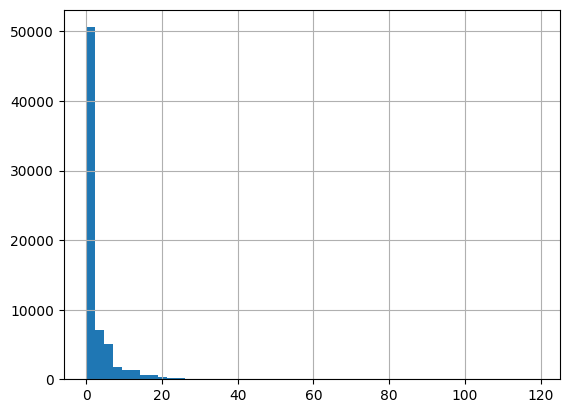

In [12]:
#Histogram of the crime count with bins of 50. 
import matplotlib.pyplot as plt
crime_grid["crime_count"].hist(bins=50)

<h2>Baseline Regression Model</h2>
<p>Training a linear regression model using the sklearn package. The purpose is to create a baseline model as a reference point as we build future models.</p>

In [13]:
#We decided to split our data based off time rather than randomly because crime data is temporal. 
#If we split it randomly, the model would train on future data and predict the past, which would leak information and make our model look better than it actually is. 
#Splitting on the year 2023 keeps the timeline intact and gives us a realistic picture of how the model would perform on unseen future data.
#We chose the year 2023 to split it on (halfway between 2020 and 2025). 
train = crime_grid[crime_grid["year"] <= 2023]
test = crime_grid[crime_grid["year"] > 2023]


#The data is split about 75/25 with 75% of the data going to the training set and 25% going to the test set. 
print(train.shape)
print(test.shape)

(51198, 9)
(18285, 9)


In [ ]:
#This is setting up the feature matrix and target variables for modeling.
#We are doing this to keep the temporal integrity we established earlier when we split the data into train and test. 
features = ["lat_grid", "lon_grid", "month", "lag_1", "lag_3", "lag_6"]

X_train = train[features]
y_train = train["crime_count"]

X_test = test[features]
y_test = test["crime_count"]

In [ ]:
#This is training our Linear Regression model on our training data.
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()

reg_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
#This makes predictions on the model we just ran. 
pred_reg = reg_model.predict(X_test)

In [ ]:
#This is evaluating how well our model performed on the test set.
#MAE compares each predicted value to the actual value whereas RMSE squares the differences before averaging and is harsher large errors. 
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, pred_reg)
rmse = np.sqrt(mean_squared_error(y_test, pred_reg))

print("Regression MAE:", mae)
print("Regression RMSE:", rmse)

Regression MAE: 1.0551962458018764
Regression RMSE: 2.3856052556637173


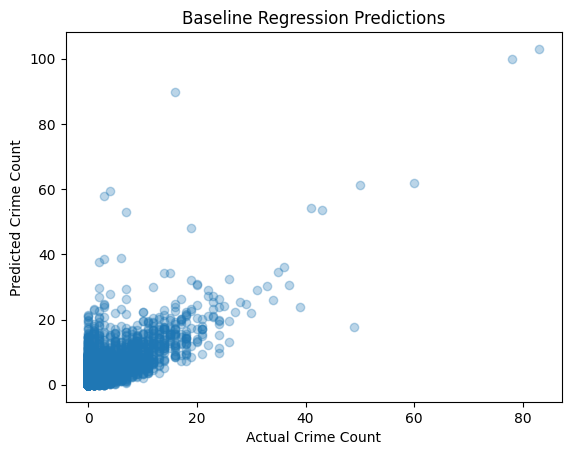

In [ ]:
#This visualizes our predictions vs. actual data points. 
import matplotlib.pyplot as plt

plt.scatter(y_test, pred_reg, alpha=0.3)
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Baseline Regression Predictions")
plt.show()

In [ ]:
#This code makes a df of the variable coefficients to create a multiple linear regression model.
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": reg_model.coef_
})

coef_df

,Feature,Coefficient
0,lat_grid,-0.058331
1,lon_grid,0.603371
2,month,-0.006252
3,lag_1,0.380482
4,lag_3,0.311335
5,lag_6,0.268508


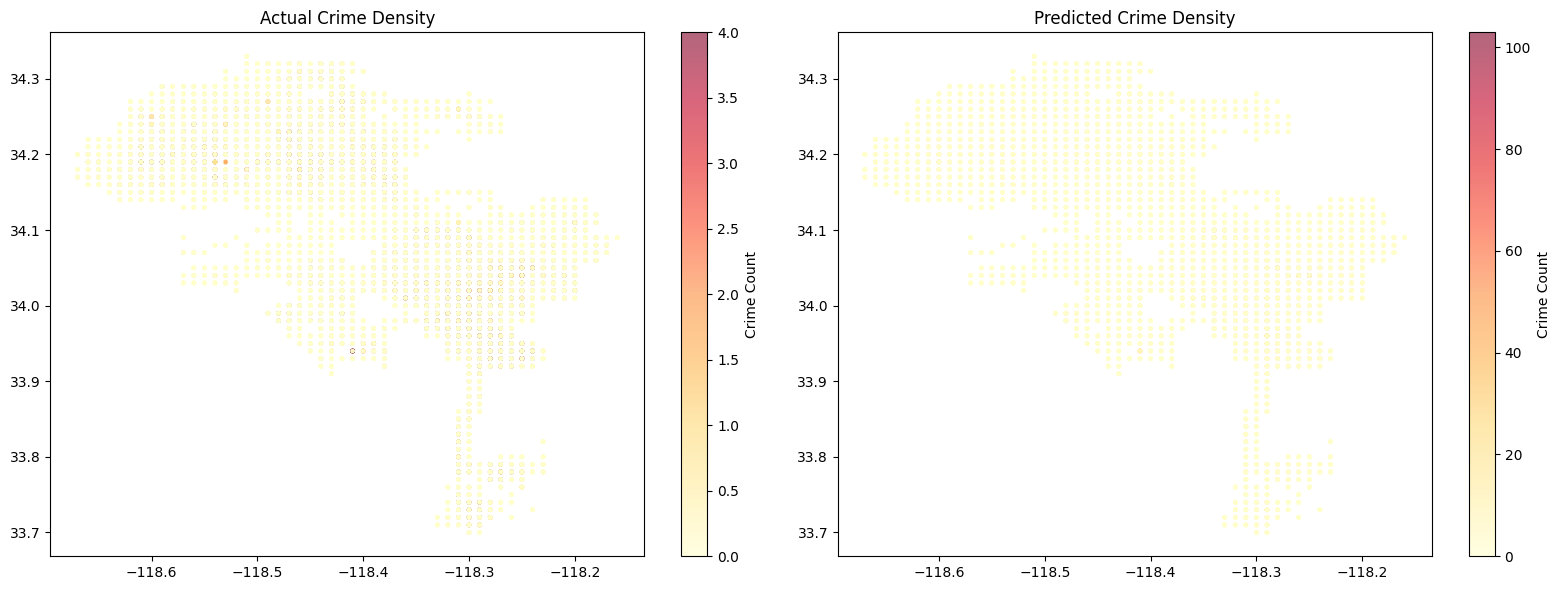

In [ ]:
#Hotspot Map
#We wanted to look at the locations of where crime actually happens versus where it is predicted to happen. 
#We used the coordinates that were given in the data set to map LA and visualize the hotspots.
#The results show some red spots but for the most part, it's very few crimes. 
results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = pred_reg
results["error"] = results["actual"] - results["predicted"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Actual
scatter1 = axes[0].scatter(
    results["lon_grid"], results["lat_grid"],
    c=results["actual"], cmap="YlOrRd", s=5, alpha=0.6,
    vmin=0, vmax=np.percentile(results["actual"], 95)  # cap at 95th percentile
)
axes[0].set_title("Actual Crime Density")
plt.colorbar(scatter1, ax=axes[0], label="Crime Count")

#Predicted
scatter2 = axes[1].scatter(
    results["lon_grid"], results["lat_grid"],
    c=results["predicted"], cmap="YlOrRd", s=5, alpha=0.6
)
axes[1].set_title("Predicted Crime Density")
plt.colorbar(scatter2, ax=axes[1], label="Crime Count")

plt.tight_layout()
plt.show()

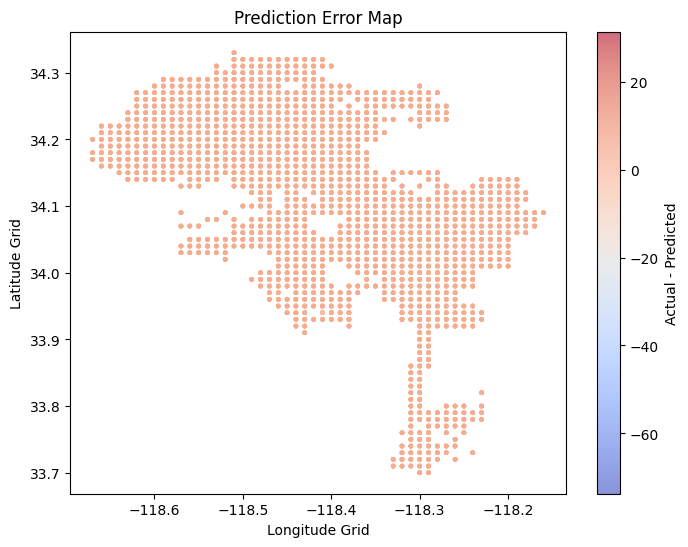

In [ ]:
#This is a prediction error map that shows where our model is under-predicting or over-predicting.
#Our model is under-predicting everywhere which just means linear regression is too simple of an analysis method. 
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    results["lon_grid"], results["lat_grid"],
    c=results["error"], cmap="coolwarm", s=5, alpha=0.6
)
plt.colorbar(scatter, label="Actual - Predicted")
plt.title("Prediction Error Map")
plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.show()

<h3>Writeup</h3>
<p>MAE: 1.055 <br>
RMSE: 2.3386 <br>
Our MAE (mean absolute error) tells us that our model's predicted crime count for a grid cell in a given month is off by about 1 crime incident. our median crime count is around 1 which would suggest this is a reasonable baseline performance. <br>
Our RMSE (root mean squared error) is larger than our MAE because larger prediciton errors are penalized more heavily. Our value suggests that most predicitons are fairly close to the actual value, but some high-crime months create larger error. This is expected because crime distributions are highly skewed. <br>
    
Scatter Plot: <br>
A lot of our points are clustered near 0-5 crimes. We also see several outliers where the model is over predicting crime. This suggests that our regression can capture general trends but is struggling with non linear crime spikes. <br>

Coefficient Interpretation: crime_count = -0.058(lat_grid) + 0.603(lon_grid) - 0.006(month) + 0.380(lag_1) + 0.311(lag_3) + 0.269(lag_6) <br>
The small value for our lat_grid -0.058 suggests that the grid cells located slightly farther north may have slightly lower predicited assault counts. However, it is important to note that the magnitude is so small that it does not strongly influence predicitions. <br>
The long_grid value of 0.603 indicates that crime counts tend to increase slightly as grid cells move east-west across the city which may reflect the spatial clustering of assaults in certain urban areas. <br>
The big takeaway is that recent crime history is the strongest predictor, which aligns with we read before we started this project, something called the "near repeat" phenomenon that crime tends to cluster in time and space.
</p>

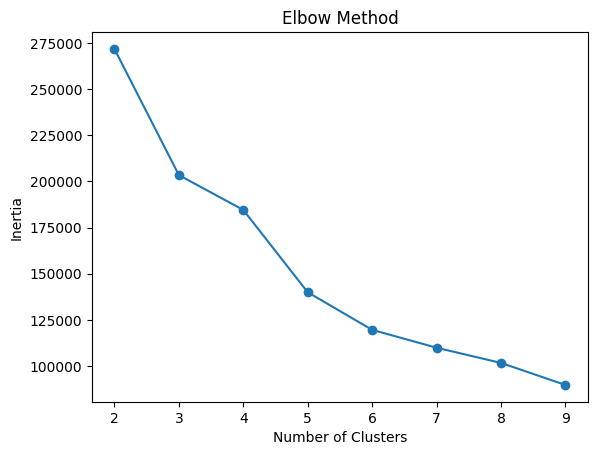

In [ ]:
#Because our linear regression results weren't the best, we decided to try clustering because it naturally fits with this type of data. 
#We first scaled our features. 
#We chose the elbow method to find the optimal number of clusters. We also wanted to use a silhouette score to make sure we pick the correct amount of clusters (and the elbow method didn't really show an elbow).
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

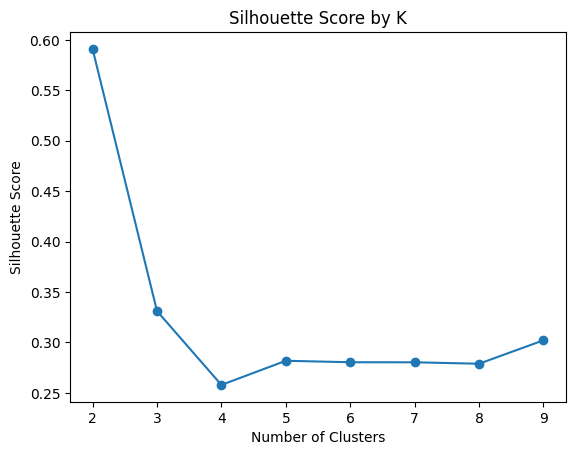

In [32]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.show()


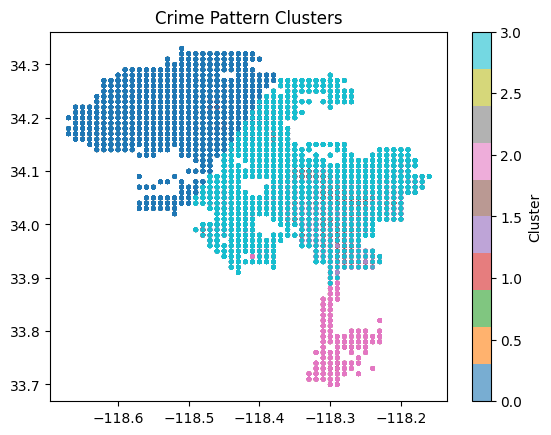

In [ ]:
#We went with 4 clusters. 
cluster_features = ["lat_grid", "lon_grid", "crime_count", "lag_1", "lag_3", "lag_6"]
X_cluster = crime_grid[cluster_features]

kmeans = KMeans(n_clusters=4, random_state=42)
crime_grid["cluster"] = kmeans.fit_predict(X_scaled)

plt.scatter(
    crime_grid["lon_grid"], crime_grid["lat_grid"],
    c=crime_grid["cluster"], cmap="tab10", s=5, alpha=0.6
)
plt.title("Crime Pattern Clusters")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
#This looks at the means of our clusters. 
#Looking at each cluster: Cluster 0 has low crime across all areas (about 1.4). Cluster 1 has the most crimes at 18. Cluster 2 has a medium amount of crimes (about 3.8). And Cluster 3 has the lowest amount of crimes at a little under 1. 
crime_grid.groupby("cluster")[["crime_count", "lag_1", "lag_3", "lag_6"]].mean()

,crime_count,lag_1,lag_3,lag_6
cluster,,,,
0,1.380337,1.413866,1.465591,1.548496
1,18.043755,18.310528,18.561920,18.517104
2,3.890329,3.992236,4.240145,4.615135
3,0.701330,0.720429,0.777923,0.914671


Next Steps:
We started out just running a linear regression to try and understand our data and how it works. We quickly realized with our visualizations and regression results that this is not enough, we need to do something more complex. We also looked at a clustering model to see if we can identify any hotspots by unsupervised methods. We chose 4 clusters and were able to find means that have around the same crime counts. So for our next steps, we want to try running an more advanced model such as Random Forest or XGBoost to be able to handle the nonlinear relationship between the lag variables and crime counts. This would hopefully reduce the overwhelming presence over underpredicition in our current model. We would probably still incorporate clustering into our random forest model to make more accurate predicitions within each cluster. 